In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load listings.csv: clean price column (remove "$" and ","), convert to float

In [2]:
df_l=pd.read_csv('/content/listings.csv')
df_c=pd.read_csv('/content/calendar.csv')
df_r=pd.read_csv('/content/reviews.csv')

In [3]:
df_l.head()

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,review_scores_value,requires_license,license,jurisdiction_names,instant_bookable,cancellation_policy,require_guest_profile_picture,require_guest_phone_verification,calculated_host_listings_count,reviews_per_month
0,241032,https://www.airbnb.com/rooms/241032,20160104002432,2016-01-04,Stylish Queen Anne Apartment,NaN,Make your self at home in this charming one-be...,Make your self at home in this charming one-be...,none,NaN,...,10.0,f,NaN,WASHINGTON,f,moderate,f,f,2,4.07
1,953595,https://www.airbnb.com/rooms/953595,20160104002432,2016-01-04,Bright & Airy Queen Anne Apartment,Chemically sensitive? We've removed the irrita...,"Beautiful, hypoallergenic apartment in an extr...",Chemically sensitive? We've removed the irrita...,none,"Queen Anne is a wonderful, truly functional vi...",...,10.0,f,NaN,WASHINGTON,f,strict,t,t,6,1.48
2,3308979,https://www.airbnb.com/rooms/3308979,20160104002432,2016-01-04,New Modern House-Amazing water view,New modern house built in 2013. Spectacular s...,"Our house is modern, light and fresh with a wa...",New modern house built in 2013. Spectacular s...,none,Upper Queen Anne is a charming neighborhood fu...,...,10.0,f,NaN,WASHINGTON,f,strict,f,f,2,1.15
3,7421966,https://www.airbnb.com/rooms/7421966,20160104002432,2016-01-04,Queen Anne Chateau,A charming apartment that sits atop Queen Anne...,NaN,A charming apartment that sits atop Queen Anne...,none,NaN,...,NaN,f,NaN,WASHINGTON,f,flexible,f,f,1,NaN
4,278830,https://www.airbnb.com/rooms/278830,20160104002432,2016-01-04,Charming craftsman 3 bdm house,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,Cozy family craftman house in beautiful neighb...,none,We are in the beautiful neighborhood of Queen ...,...,9.0,f,NaN,WASHINGTON,f,strict,f,f,1,0.89


In [4]:
df_l.isnull().sum()

,0
id,0
listing_url,0
scrape_id,0
last_scraped,0
name,0
...,...
cancellation_policy,0
require_guest_profile_picture,0
require_guest_phone_verification,0
calculated_host_listings_count,0


In [5]:
df_l['price']

,price
0,$85.00
1,$150.00
2,$975.00
3,$100.00
4,$450.00
...,...
3813,$359.00
3814,$79.00
3815,$93.00
3816,$99.00


In [6]:
df_l['price']=df_l['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df_l['price']

,price
0,85.0
1,150.0
2,975.0
3,100.0
4,450.0
...,...
3813,359.0
3814,79.0
3815,93.0
3816,99.0


#Load calendar.csv: convert date to datetime; convert available ("t"/"f") to binary

In [7]:
df_c

,listing_id,date,available,price
0,241032,2016-01-04,t,$85.00
1,241032,2016-01-05,t,$85.00
2,241032,2016-01-06,f,NaN
3,241032,2016-01-07,f,NaN
4,241032,2016-01-08,f,NaN
...,...,...,...,...
1393565,10208623,2016-12-29,f,NaN
1393566,10208623,2016-12-30,f,NaN
1393567,10208623,2016-12-31,f,NaN
1393568,10208623,2017-01-01,f,NaN


In [8]:
df_c.dtypes

,0
listing_id,int64
date,object
available,object
price,object


In [9]:
df_c['date']=pd.to_datetime(df_c['date'])

In [10]:
df_c['available']=df_c['available'].map({'t': True, 'f': False})

#Calculate occupancy rate per listing: % of days where available = False

In [11]:
df_c

,listing_id,date,available,price
0,241032,2016-01-04,True,$85.00
1,241032,2016-01-05,True,$85.00
2,241032,2016-01-06,False,NaN
3,241032,2016-01-07,False,NaN
4,241032,2016-01-08,False,NaN
...,...,...,...,...
1393565,10208623,2016-12-29,False,NaN
1393566,10208623,2016-12-30,False,NaN
1393567,10208623,2016-12-31,False,NaN
1393568,10208623,2017-01-01,False,NaN


In [12]:
df_r

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,7202016,38917982,2015-07-19,28943674,Bianca,Cute and cozy place. Perfect location to every...
1,7202016,39087409,2015-07-20,32440555,Frank,Kelly has a great room in a very central locat...
2,7202016,39820030,2015-07-26,37722850,Ian,"Very spacious apartment, and in a great neighb..."
3,7202016,40813543,2015-08-02,33671805,George,Close to Seattle Center and all it has to offe...
4,7202016,41986501,2015-08-10,34959538,Ming,Kelly was a great host and very accommodating ...
...,...,...,...,...,...,...
84844,3624990,50436321,2015-10-12,37419458,Ryan,The description and pictures of the apartment ...
84845,3624990,51024875,2015-10-17,6933252,Linda,We had an excellent stay. It was clean and com...
84846,3624990,51511988,2015-10-20,19543701,Jaime,"Gran ubicación, cerca de todo lo atractivo del..."
84847,3624990,52814482,2015-11-02,24445024,Jørgen,"Very good apartement, clean and well sized. Si..."


In [13]:
occupancy = (
    df_c.groupby('listing_id')['available']
    .apply(lambda x: (x == False).sum() / len(x))
    .reset_index()
    .rename(columns={'available': 'occupancy_rate'})
)

In [14]:
occupancy

,listing_id,occupancy_rate
0,3335,0.153425
1,4291,0.000000
2,5682,0.153425
3,6606,0.000000
4,7369,0.854795
...,...,...
3813,10332096,0.000000
3814,10334184,0.010959
3815,10339144,1.000000
3816,10339145,0.000000


#Merge occupancy rates back to listings on listing_id

In [15]:
df_l=df_l.merge(occupancy, left_on='id', right_on='listing_id', how='left')
df_l[['id', 'neighbourhood_cleansed', 'price', 'occupancy_rate']].head()

,id,neighbourhood_cleansed,price,occupancy_rate
0,241032,West Queen Anne,85.0,0.052055
1,953595,West Queen Anne,150.0,0.202740
2,3308979,West Queen Anne,975.0,0.397260
3,7421966,West Queen Anne,100.0,0.608219
4,278830,West Queen Anne,450.0,0.000000


#Aggregate by neighbourhood: median price, avg occupancy rate, listing count

In [16]:
df_l.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary',
       'space', 'description', 'experiences_offered', 'neighborhood_overview',
       'notes', 'transit', 'thumbnail_url', 'medium_url', 'picture_url',
       'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since',
       'host_location', 'host_about', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood',
       'host_listings_count', 'host_total_listings_count',
       'host_verifications', 'host_has_profile_pic', 'host_identity_verified',
       'street', 'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market',
       'smart_location', 'country_code', 'country', 'latitude', 'longitude',
       'is_location_exact', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', '

In [17]:
df_l['neighbourhood_cleansed']

,neighbourhood_cleansed
0,West Queen Anne
1,West Queen Anne
2,West Queen Anne
3,West Queen Anne
4,West Queen Anne
...,...
3813,Fremont
3814,Portage Bay
3815,Rainier Beach
3816,Madison Park


In [18]:
neighbourhood_stats=df_l.groupby('neighbourhood_cleansed').agg(
    median_price   = ('price', 'median'),
    avg_occupancy  = ('occupancy_rate', 'mean'),
    listing_count  = ('id', 'count')
).reset_index()

neighbourhood_stats

,neighbourhood_cleansed,median_price,avg_occupancy,listing_count
0,Adams,99.5,0.383836,70
1,Alki,126.5,0.265819,42
2,Arbor Heights,100.0,0.238356,5
3,Atlantic,95.0,0.390695,53
4,Belltown,139.0,0.375717,234
...,...,...,...,...
82,West Woodland,95.0,0.314683,64
83,Westlake,150.0,0.388880,17
84,Whittier Heights,110.0,0.308851,26
85,Windermere,127.5,0.274795,10


#Find top 5 and bottom 5 neighbourhoods by median price

In [19]:
neighbourhood_stats=neighbourhood_stats.sort_values(by='median_price', ascending=False)
top5 = neighbourhood_stats.head(5)
bottom5 = neighbourhood_stats.tail(5)

In [20]:
top5

,neighbourhood_cleansed,median_price,avg_occupancy,listing_count
6,Briarcliff,173.5,0.134638,14
83,Westlake,150.0,0.388880,17
32,Industrial District,150.0,0.143836,6
60,Pioneer Square,150.0,0.212150,23
73,Southeast Magnolia,150.0,0.183562,17


In [21]:
bottom5

,neighbourhood_cleansed,median_price,avg_occupancy,listing_count
5,Bitter Lake,65.0,0.359326,13
77,Victory Heights,65.0,0.196712,15
62,Rainier Beach,60.0,0.270624,18
69,South Beacon Hill,60.0,0.497945,4
56,Olympic Hills,55.5,0.233904,16


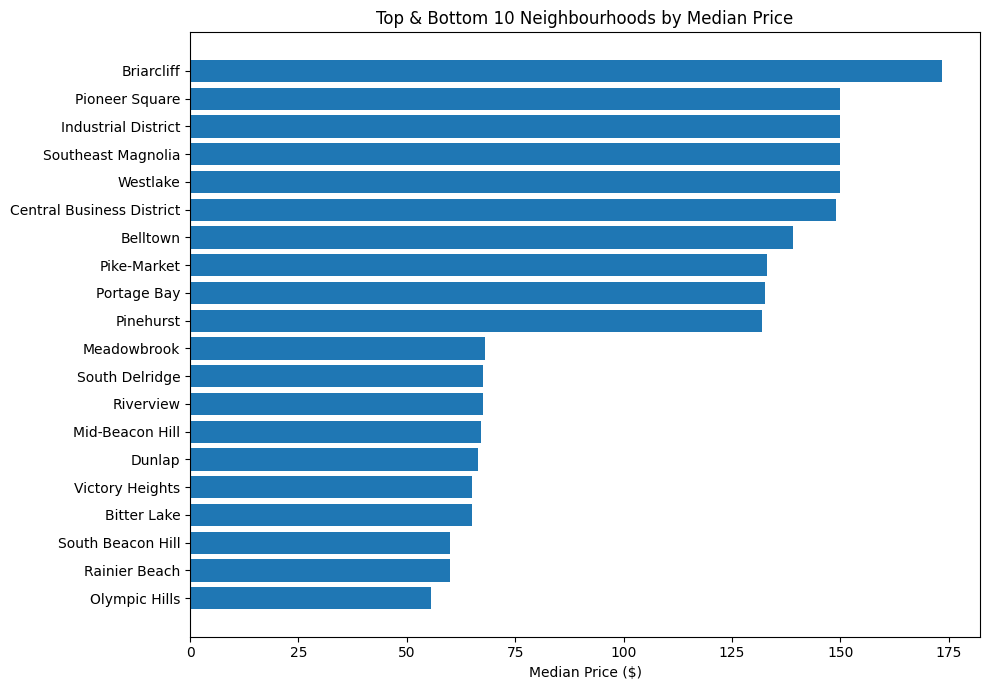

In [22]:
top10 = neighbourhood_stats.head(10)
bottom10 = neighbourhood_stats.tail(10)
combined = pd.concat([top10, bottom10]).drop_duplicates()
combined = combined.sort_values('median_price')

plt.figure(figsize=(10, 7))
plt.barh(combined['neighbourhood_cleansed'], combined['median_price'])
plt.xlabel('Median Price ($)')
plt.title('Top & Bottom 10 Neighbourhoods by Median Price')
plt.tight_layout()
plt.show()

Ən baha rayon (173) ilə ən ucuz rayon (55) arasında 3x qiymət fərqi var — lokasiya seçimi investor üçün çox kritikdir.

#Analyze price by room_type: boxplot showing distribution

In [23]:
df_l[['room_type', 'price']]

,room_type,price
0,Entire home/apt,85.0
1,Entire home/apt,150.0
2,Entire home/apt,975.0
3,Entire home/apt,100.0
4,Entire home/apt,450.0
...,...,...
3813,Entire home/apt,359.0
3814,Entire home/apt,79.0
3815,Entire home/apt,93.0
3816,Entire home/apt,99.0


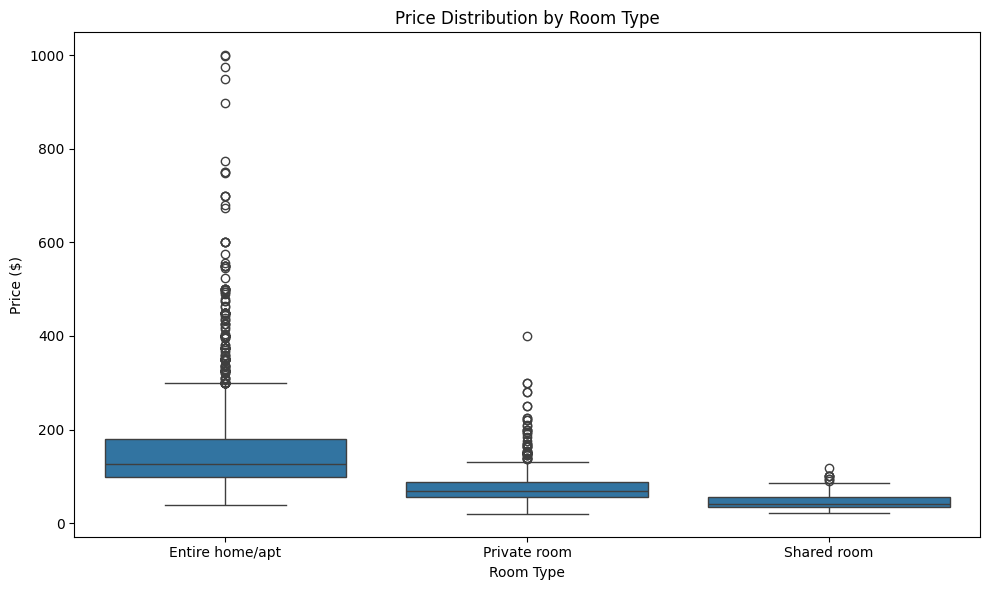

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_l, x='room_type', y='price')
plt.title('Price Distribution by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()
plt.show()

Qrafikdən vizual olaraq görünür ki, bütöv ev/mənzil kirayəsi bazarın ən gəlirli sahəsidir. Bu kateqoriyanın median qiyməti (təxminən $125) digər otaq tiplərinin maksimum hədlərindən belə yüksəkdir. Biz bu fərqi onunla izah edirik ki, müştərilər tam məxfilik (privacy) faktoruna görə ciddi şəkildə premium qiymət ödəməyə meyllidirlər.

Entire home/apt qutusunun hündürlüyü çox genişdir (təxminən 100 ilə 180 arası). Private room və Shared room hissəsində isə qutular çox ensiz və sıxılmış formadadır.

Bu fərqlilik onu göstərir ki, bütöv mənzili olan ev sahibləri qiymətləri qaldırıb-endirməkdə çox rahatdırlar və geniş hərəkət imkanları var. Fərdi və müştərək otaqlarda isə qiymət aralığı çox dardır; çünki bu seqmentdə müştəri qazanmağın tək yolu yalnız qiyməti maksimum dərəcədə ucuz tutmaq və rəqiblərdən baha qoymamaqdır.

Entire home/apt sütununun yuxarı hissəsində, 400-dən 1000-ə qədər uzanan çoxlu sayda outlier nöqtələri müşahidə edirik.

Bu nöqtələr təsadüfi xətalar deyil, Sietl bazarında xüsusi bir "Lüks/Premium" (məsələn, böyük qruplar üçün villalar və ya penthauslar) seqmentinin olduğunu sübut edir. Şəxsi və müştərək otaqlarda isə price ceiling(təbii olaraq formalaşmış maksimum qiymət həddi) $200 civarında tamamilə qırılır.

Shared room (müştərək otaqlar) qrafikinin həm median xətti ($50-dən aşağı), həm də ümumi yayılımı minimaldır.

Bu sahə risk səviyyəsinin aşağı olması ilə cəlbedici görünsə də, digər yüksək gəlirli mülklərin müqayisəsi önündə (və ya Entire home seqmentinin önündə) qazanc potensialı baxımından oldukça zəif və geridə qalan bir seqmentdir. Bazar tamamilə büdcəli şəxslərə xidmət edir və price ceiling-i keçmək imkanımız demək olar ki, yoxdur.

#Calculate monthly median price from calendar.csv to show seasonal variation

In [ ]:
df_c['price']=df_c['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)
df_c['price']

In [ ]:
df_c['month'] = df_c['date'].dt.to_period('M')

monthly_price = df_c.groupby('month')['price'].median().reset_index()
monthly_price.columns = ['month', 'median_price']

In [ ]:
monthly_price

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_price['month'].astype(str), monthly_price['median_price'], marker='o')
plt.title('Monthly Median Price')
plt.xlabel('Month')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Qiymətlər ilin əvvəlindən başlayaraq yay aylarına doğru sürətlə yüksəlir və iyul ayında 115$ ilə zirvəyə çatır. Sietl yay turizmi üçün aktiv bir şəhər olduğundan, tələb artır və bu da birbaşa qiymətləri yuxarı daşıyır.

Qrafikdə maraqlı bir hissə may ayında deyil, elə aprel ayında baş verir (qiymət birdən-birə 100$-dan 110$-a qalxır). Ola bilər ki, şəhərdə yaz mövsümünün və biznes aktivliyinin başlaması hostların qiyməti erkəndən qaldırmasına şərait yaradır.

Yay bitdikdən sonra qiymətlər enməyə başlayır və noyabr ayında ilin ən aşağı səviyyəsinə (106$) düşür. Dekabrda bayramlarla əlaqədar kiçik bir canlanma olsa da, ümumi qış mövsümü zəif keçir.

#Compare instant_bookable listings vs non-instant: price and occupancy

In [ ]:
instant_stats = df_l.groupby('instant_bookable').agg(
    median_price  = ('price', 'median'),
    avg_occupancy = ('occupancy_rate', 'mean')
).reset_index()

instant_stats

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(['Non-Instant', 'Instant'], instant_stats['median_price'])
ax1.set_title('Median Price')
ax1.set_ylabel('Price ($)')

ax2.bar(['Non-Instant', 'Instant'], instant_stats['avg_occupancy'])
ax2.set_title('Avg Occupancy Rate')
ax2.set_ylabel('Occupancy Rate')

plt.tight_layout()
plt.show()

Instant bookable ilə non-instant arasında demək olar ki, heç bir fərq yoxdur — nə qiymətdə, nə də tutulmada.

Bu o deməkdir ki, instant bookable aktiv etmək nə qiyməti aşağı salır, nə də tutulmanı artırır — host üçün risksiz bir seçimdir, istəsə aktiv edə bilər.

**Correlate number_of_reviews with occupancy rate**

In [ ]:
corr = df_l['number_of_reviews'].corr(df_l['occupancy_rate'])
corr

Korrelyasiya: -0.094

Bu çox zəif mənfi korrelyasiyadır. Yəni:

Review sayı artdıqca occupancy rate çox az azalır

Amma bu əlaqə demək olar ki, yoxdur (-0.094 sıfıra çox yaxındır)

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df_l['number_of_reviews'], df_l['occupancy_rate'], alpha=0.3)
plt.title('Number of Reviews vs Occupancy Rate')
plt.xlabel('Number of Reviews')
plt.ylabel('Occupancy Rate')
plt.tight_layout()
plt.show()

Qrafikdən görünən:

Əksər evlərin review sayı 0-100 arasındadır

Review sayı çox olan evlərin occupancy rate-i hər yerdə yayılıb — aydın bir pattern yoxdur

Yəni çox review = yüksək occupancy demək deyil



Review sayı evin nə qədər tutulduğunu proqnozlaşdırmır. Ev sahibi review toplamağa fokuslanmaq əvəzinə qiymət və lokasiyaya diqqət etməlidir.

In [ ]:
df_l['occupancy_rate']

In [ ]:
# Revenue potential hesabla
df_l['revenue_potential'] = df_l['occupancy_rate'] * df_l['price'] * 365

# Neighbourhood üzrə ortalama revenue potential
revenue_by_neighbourhood = df_l.groupby('neighbourhood_cleansed').agg(
    avg_revenue = ('revenue_potential', 'mean'),
    median_price = ('price', 'median'),
    avg_occupancy = ('occupancy_rate', 'mean')
).reset_index().sort_values('avg_revenue', ascending=False)

print("TOP 10 - Ən yüksək revenue potential:")
revenue_by_neighbourhood.head(10)

5 INSIGHTS FOR HOST / PROPERTY INVESTOR

1. LOKASİYA HƏR ŞEYDİR

   Briarcliff (173) və Olympic Hills (55) arasında
   3x qiymət fərqi var. Mərkəzə yaxın əmlak almaq
   ən böyük gəlir artımını təmin edir.

2. TAM EV İCARƏSİ 2X DAHA ÇOX QAZANDIRIR

   Entire home median qiyməti (130) private room-dan
   (65) 2x yüksəkdir. Mümkünsə tam evi icarəyə ver.

3. YAYDA DİNAMİK QİYMƏT TƏTBİQ ET

   Yay aylarında (İyun-Avqust) qiymətlər ən yüksək
   səviyyəyə çatır. Bu dövrdə 15-20% qiymət artımı
   əlavə gəlir gətirər. Qışda isə endirim et.

4. INSTANT BOOKABLE RİSKSİZ AKTİV ET

   Instant bookable olan və olmayan evlər arasında
   qiymət ($100 vs $99) və occupancy (32.9% vs 32.6%)
   fərqi minimaldır. Qonaq üçün rahatdır — aktiv et.

5. REVENUE POTENSİALI = QİYMƏT × OCCUPANCY × 365

   Yalnız yüksək qiymətə fokuslanma. Bəzən orta
   qiymətli amma yüksək occupancy-li rayon daha çox
   gəlir gətirir. Hər iki metrikə birlikdə bax.